In [121]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.matrixlib import test
# ---
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

---
# 1. Carregamento do Dataset

In [122]:
# Carregar o Dataset

df = pd.read_csv('marketing.csv')

df['media_cliques'] = (df['cliques'] / df['anuncios'])
df['foram_relevantes'] = (df['media_cliques'] > 3)

df.sort_values(["media_cliques"], ascending=False)

,anuncios,cliques,media_cliques,foram_relevantes
19,6,81,13.500000,True
54,18,133,7.388889,True
72,6,43,7.166667,True
83,18,120,6.666667,True
99,49,307,6.265306,True
...,...,...,...,...
80,48,111,2.312500,False
68,168,171,1.017857,False
81,166,165,0.993976,False
33,174,161,0.925287,False


In [123]:
print(f"Shape: {df.shape}\n\nColumns: {df.columns}\n\nInfo: \n{df.info}\n\nDescribe:{df.describe()}")

Shape: (100, 4)

Columns: Index(['anuncios', 'cliques', 'media_cliques', 'foram_relevantes'], dtype='object')

Info: 
<bound method DataFrame.info of     anuncios  cliques  media_cliques  foram_relevantes
0        107      315       2.943925             False
1        184      613       3.331522              True
2         97      352       3.628866              True
3         19       98       5.157895              True
4        111      322       2.900901             False
..       ...      ...            ...               ...
95       128      357       2.789062             False
96        45      165       3.666667              True
97       161      527       3.273292              True
98        19       71       3.736842              True
99        49      307       6.265306              True

[100 rows x 4 columns]>

Describe:         anuncios     cliques  media_cliques
count  100.000000  100.000000     100.000000
mean   100.780000  315.320000       3.442121
std     59.368491  1

In [124]:
print(f"Value Counts:")
df.value_counts()

Value Counts:


anuncios  cliques  media_cliques  foram_relevantes
6         43       7.166667       True                1
          81       13.500000      True                1
8         30       3.750000       True                1
12        37       3.083333       True                1
13        49       3.769231       True                1
                                                     ..
194       600      3.092784       True                1
          641      3.304124       True                1
          660      3.402062       True                1
195       562      2.882051       False               1
196       631      3.219388       True                1
Name: count, Length: 100, dtype: int64

In [132]:
# Mean, Min, Max, Std, Median

print("Analise de Média de Cliques:\n")
print(f"Média: {df["media_cliques"].mean()}")
print(f"Minimo: {df["media_cliques"].min()}")
print(f"Maximo: {df['media_cliques'].max()}")
print(f"Desvio Padrão: {df['media_cliques'].std()}")
print(f"Mediana: {df['media_cliques'].median()}\n\n")

# ----------------------------------------------------------

print("Analise de anuncios:\n")
print(f"Média: {df["anuncios"].mean()}")
print(f"Minimo: {df["anuncios"].min()}")
print(f"Maximo: {df['anuncios'].max()}")
print(f"Desvio Padrão: {df['anuncios'].std()}")
print(f"Mediana: {df['anuncios'].median()}")

Analise de Média de Cliques:

Média: 3.442121348340009
Minimo: 0.7142857142857143
Maximo: 13.5
Desvio Padrão: 1.4441722444206508
Mediana: 3.2196938775510207


Analise de anuncios:

Média: 100.78
Minimo: 6
Maximo: 196
Desvio Padrão: 59.368491456140084
Mediana: 96.5


---

# 2. Análise Exploratória

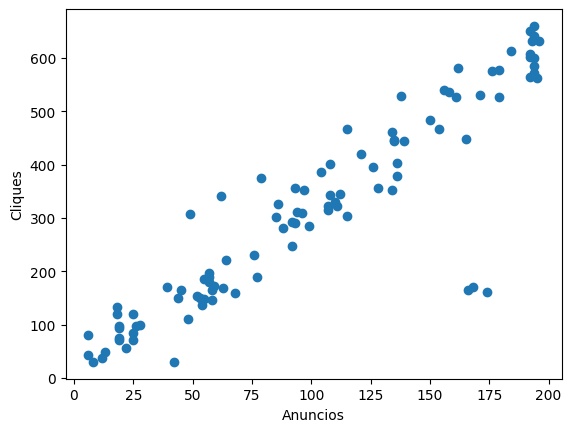

In [134]:
# Gerando gráfico

plt.scatter(df['anuncios'], df['cliques'])
plt.xlabel("Anuncios")
plt.ylabel("Cliques")
plt.show()

In [127]:
# Verificando a correlacao entre as variaveis

df.corr()

,anuncios,cliques,media_cliques,foram_relevantes
anuncios,1.000000,0.912057,-0.372015,-0.039934
cliques,0.912057,1.000000,-0.139317,0.205863
media_cliques,-0.372015,-0.139317,1.000000,0.437905
foram_relevantes,-0.039934,0.205863,0.437905,1.000000


---

# 3.Preparação dos Dados:

In [128]:
# Separar as variáveis independentes(X) da variavel alvo(Y)

x = df[['anuncios']]
y = df[['foram_relevantes']]


# Dividir o dataset em treino e teste

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.3,
    random_state=45
)


---

# 4.Treinamento do Modelo

In [129]:
modelo = LogisticRegression()
modelo.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [130]:
y_pred = modelo.predict(x_test)

print(f"Previsões")
print(f"{y_pred}")
print(f"{y_test}")

Previsões
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]
    foram_relevantes
0              False
1               True
62              True
76              True
37              True
99              True
78             False
38              True
2               True
84             False
60              True
26              True
69             False
33             False
51             False
4              False
92              True
7               True
10              True
74             False
45              True
9               True
20              True
18              True
73              True
19              True
25              True
21              True
70              True
23              True


---

# 5. Visualização do Modelo

In [137]:
# Acurácia

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc}")

# Relatório de classificação
print(f"Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.7333333333333333
Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00         8
        True       0.73      1.00      0.85        22

    accuracy                           0.73        30
   macro avg       0.37      0.50      0.42        30
weighted avg       0.54      0.73      0.62        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


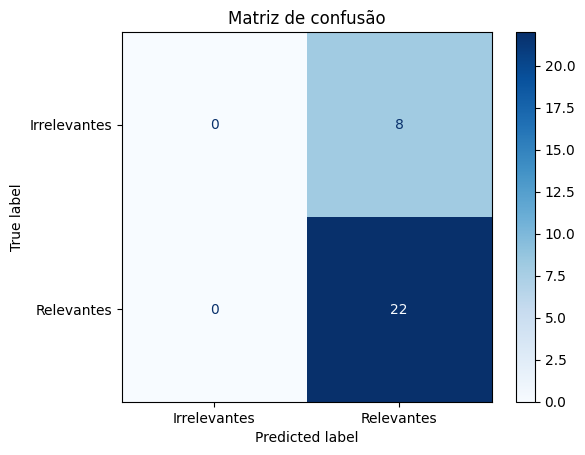

In [136]:
# Matriz de confusão

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Irrelevantes", "Relevantes"],
    cmap="Blues"
)

plt.title("Matriz de confusão")
plt.show()

---

# Interpretação:

## Dataset:
O dataset não traz informações suficientes pra poder prever se os anuncios serão relevantes ou não. Saber a quantidade de cliques por anuncio é muito pouco, já que sem duvida alguma existem diversos outros fatores que influenciam na quantidade de cliques dos anuncios; fatores esses que não temos acesso.

---

## Regressão Logística:

O modelo simplesmente prevê que está tudo "certo"; que todos anuncios são relevantes. Portanto, os resultados desse modelo são totalmente ineficientes.